# Retail Sales Data — Exploratory Data Analysis

**Objective:** Explore retail sales data to identify sales trends, customer behaviour patterns, product/category performance, and actionable business insights.

**Tech stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook.

> **How to use:** Put your dataset in the same folder as this notebook and name it `retail_sales.csv`, or change `DATA_PATH` in the first code cell. The notebook includes flexible column-name detection for common retail-sales datasets.


In [ ]:
# 1. Imports and configuration
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

DATA_PATH = "retail_sales.csv"

# Load data
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (1200, 10)


,Transaction_ID,Date,Customer_ID,Gender,Age,Product,Category,Quantity,Unit_Price,Total_Amount
0,100756,2024-01-01,1145,Male,34.0,Mouse,Accessories,1,29.44,29.44
1,100980,2024-01-01,1061,Female,18.0,Smartphone,Electronics,4,616.42,2465.68
2,100649,2024-01-01,1191,Female,36.0,Tablet,Electronics,1,431.99,431.99
3,101138,2024-01-01,1145,Male,39.0,Backpack,Lifestyle,1,76.41,76.41
4,100213,2024-01-02,1136,Female,19.0,Headphones,Electronics,3,90.62,271.86


## 1. Initial inspection

The first step is to understand the dataset structure, data types, missingness, and duplicate records. This establishes whether the data is ready for analysis and highlights fields that may require cleaning.


In [ ]:
# Shape, dtypes, nulls, duplicates, and unique-value counts
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
null_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
display(null_summary)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
display(df.nunique().sort_values(ascending=False).to_frame("n_unique"))


Shape: (1200, 10)

Data types:


,dtype
Transaction_ID,int64
Date,object
Customer_ID,int64
Gender,object
Age,float64
Product,object
Category,object
Quantity,int64
Unit_Price,float64
Total_Amount,float64



Missing values:


,missing_count,missing_pct
Gender,8,0.67
Age,5,0.42
Date,0,0.00
Transaction_ID,0,0.00
Customer_ID,0,0.00
Product,0,0.00
Category,0,0.00
Quantity,0,0.00
Unit_Price,0,0.00
Total_Amount,0,0.00



Duplicate rows: 0

Unique values:


,n_unique
Transaction_ID,1200
Total_Amount,1191
Unit_Price,1184
Date,576
Customer_ID,248
Age,50
Product,15
Quantity,5
Category,4
Gender,3


### Observation

Review the table above for columns with substantial missing values or unexpected data types. Duplicate rows can inflate sales totals, while incorrectly typed dates or numeric fields can prevent valid time-series and statistical analysis.


In [ ]:
# 2. Flexible column detection
def find_col(candidates, columns):
    normalized = {str(c).strip().lower().replace(" ", "_"): c for c in columns}
    for candidate in candidates:
        key = candidate.lower().replace(" ", "_")
        if key in normalized:
            return normalized[key]
    # fallback: substring matching
    for c in columns:
        cl = str(c).lower().replace(" ", "_")
        if any(candidate.lower().replace(" ", "_") in cl for candidate in candidates):
            return c
    return None

DATE_COL = find_col(["date", "transaction_date", "order_date", "sale_date", "invoice_date"], df.columns)
SALES_COL = find_col(["total_amount", "sales", "revenue", "sales_amount", "amount", "total_sales"], df.columns)
QTY_COL = find_col(["quantity", "qty", "units", "units_sold"], df.columns)
AGE_COL = find_col(["age", "customer_age"], df.columns)
GENDER_COL = find_col(["gender", "sex"], df.columns)
PRODUCT_COL = find_col(["product", "product_name", "item", "item_name"], df.columns)
CATEGORY_COL = find_col(["category", "product_category", "product_type"], df.columns)
CUSTOMER_COL = find_col(["customer_id", "customer", "customerid", "client_id"], df.columns)

detected = pd.Series({
    "Date": DATE_COL,
    "Sales/Revenue": SALES_COL,
    "Quantity": QTY_COL,
    "Age": AGE_COL,
    "Gender": GENDER_COL,
    "Product": PRODUCT_COL,
    "Category": CATEGORY_COL,
    "Customer": CUSTOMER_COL
})
display(detected.to_frame("detected_column"))

if DATE_COL:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
if SALES_COL:
    df[SALES_COL] = pd.to_numeric(df[SALES_COL], errors="coerce")
if QTY_COL:
    df[QTY_COL] = pd.to_numeric(df[QTY_COL], errors="coerce")
if AGE_COL:
    df[AGE_COL] = pd.to_numeric(df[AGE_COL], errors="coerce")


,detected_column
Date,Date
Sales/Revenue,Total_Amount
Quantity,Quantity
Age,Age
Gender,Gender
Product,Product
Category,Category
Customer,Customer_ID


## 2. Descriptive statistics

For every numerical field, we calculate the mean, median, mode, and standard deviation. Comparing the mean and median is particularly useful for identifying skewness caused by unusually large transactions or quantities.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 3. Descriptive statistics for all numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if numeric_cols:
    stats = pd.DataFrame({
        "mean": df[numeric_cols].mean(),
        "median": df[numeric_cols].median(),
        "mode": [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in numeric_cols],
        "std_dev": df[numeric_cols].std()
    })
    display(stats)
else:
    print("No numerical columns were detected.")


,mean,median,mode,std_dev
Transaction_ID,100600.500000,100600.500,100001.00,346.554469
Customer_ID,1127.064167,1127.000,1077.00,73.870093
Age,36.280335,36.000,18.00,11.099108
Quantity,1.754167,1.000,1.00,1.026943
Unit_Price,293.928167,194.625,29.11,285.433679
Total_Amount,511.600758,260.950,29.52,631.047096


### Observation

Use the statistics table to identify variables with large dispersion. If a variable's mean is much higher than its median, the distribution may be right-skewed, which can indicate a small number of unusually large transactions.


## 3. Time-series analysis

Monthly and quarterly aggregation helps reveal seasonality, growth/decline periods, and recurring demand patterns. These trends can support inventory, staffing, and promotional planning.


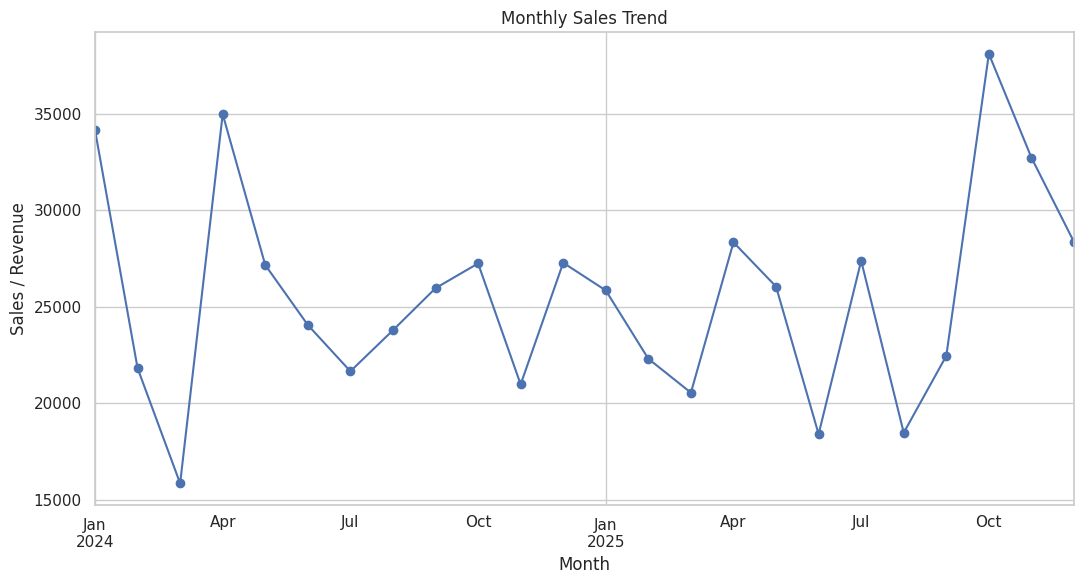

In [ ]:
# 4. Monthly sales trend
if DATE_COL and SALES_COL:
    ts = df.dropna(subset=[DATE_COL, SALES_COL]).copy()
    monthly_sales = ts.set_index(DATE_COL)[SALES_COL].resample("MS").sum()

    ax = monthly_sales.plot(marker="o")
    ax.set_title("Monthly Sales Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Sales / Revenue")
    plt.tight_layout()
    plt.show()
else:
    print("Monthly trend requires detected date and sales/revenue columns.")


### Observation

Look for sustained upward/downward movement, recurring peaks, and unusual spikes or dips. Repeated peaks in particular months suggest seasonality and may justify advance inventory and marketing planning.


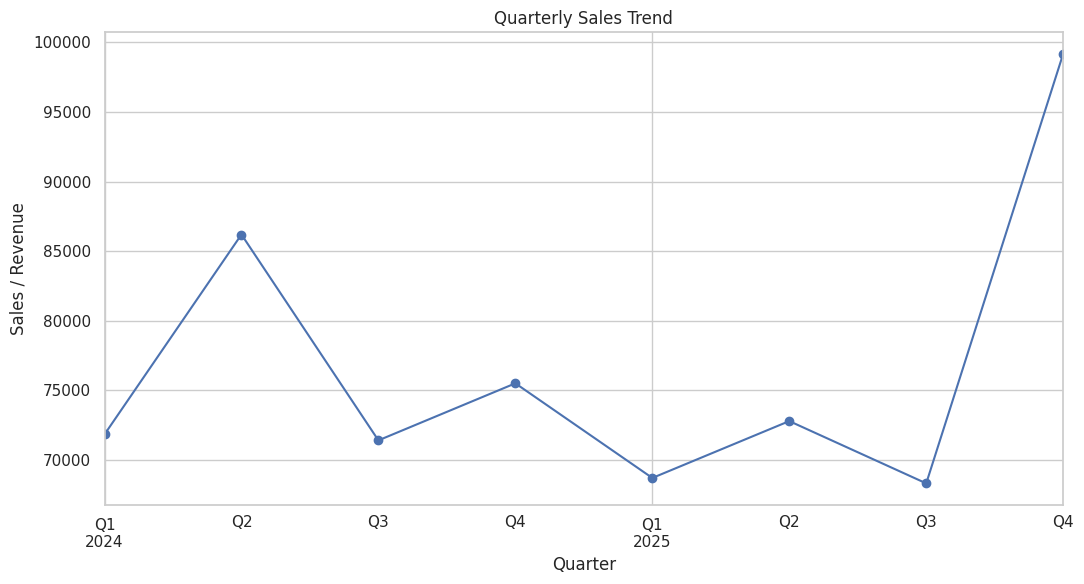

In [ ]:
# 5. Quarterly sales trend
if DATE_COL and SALES_COL:
    quarterly_sales = ts.set_index(DATE_COL)[SALES_COL].resample("QS").sum()

    ax = quarterly_sales.plot(marker="o")
    ax.set_title("Quarterly Sales Trend")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Sales / Revenue")
    plt.tight_layout()
    plt.show()
else:
    print("Quarterly trend requires detected date and sales/revenue columns.")


### Observation

Quarterly aggregation smooths short-term fluctuations. Compare consecutive quarters to identify broader growth patterns and periods where sales performance changed materially.


## 4. Customer demographics

Age and gender distributions help identify the customer segments contributing most to transaction volume. These results should be used for descriptive segmentation rather than assuming that demographic characteristics cause purchasing behaviour.


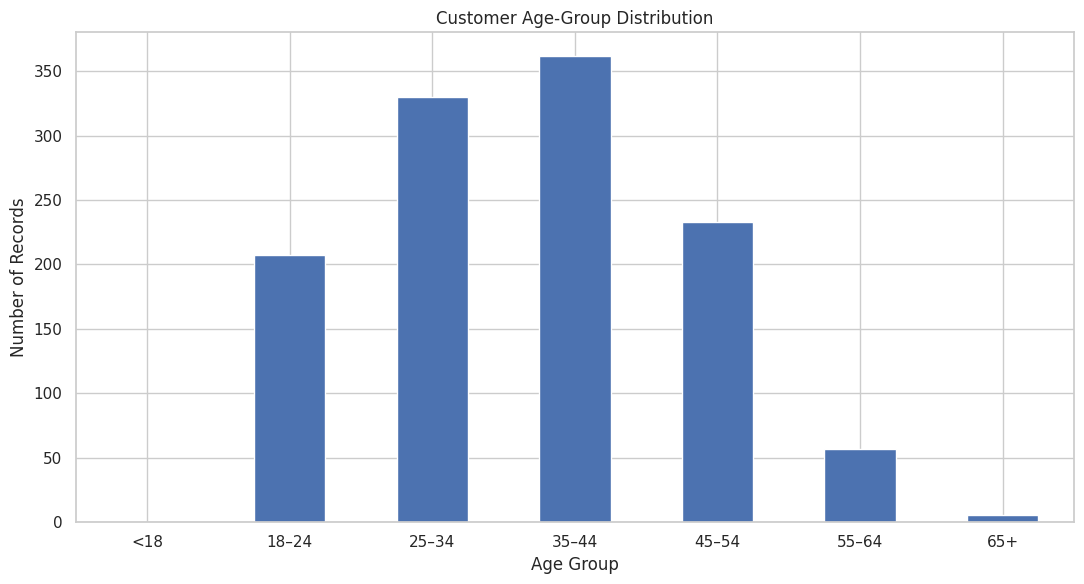

In [ ]:
# 6. Age-group distribution
if AGE_COL:
    age_bins = [0, 17, 24, 34, 44, 54, 64, np.inf]
    age_labels = ["<18", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"]

    age_groups = pd.cut(df[AGE_COL], bins=age_bins, labels=age_labels, right=True)
    age_counts = age_groups.value_counts().sort_index()

    ax = age_counts.plot(kind="bar")
    ax.set_title("Customer Age-Group Distribution")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Number of Records")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Age-group analysis requires an age column.")


### Observation

Identify the largest customer age groups and whether the customer base is concentrated in a narrow or broad range. This can inform audience segmentation and communication strategies.


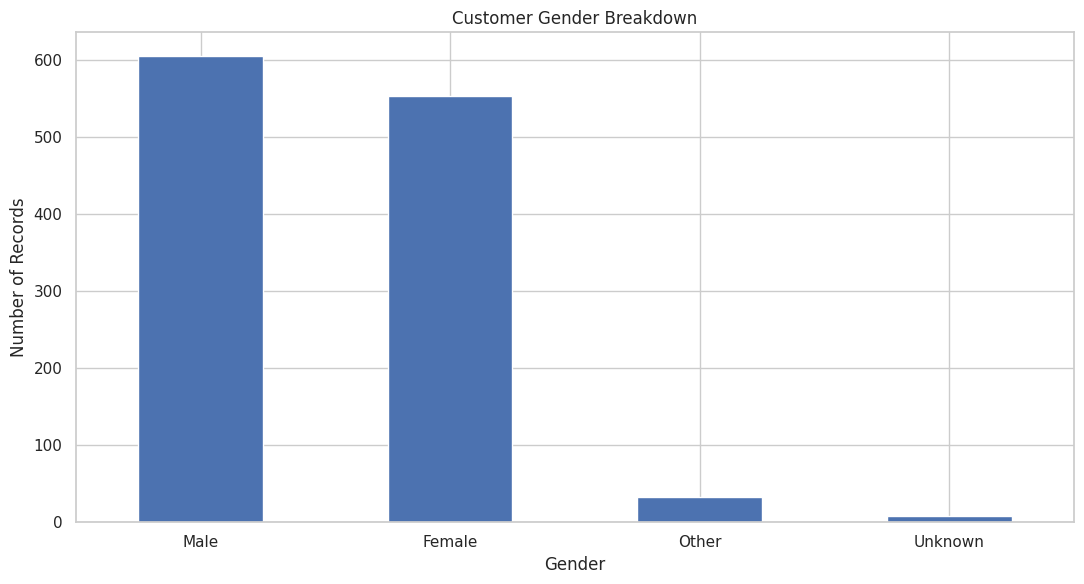

In [ ]:
# 7. Gender breakdown
if GENDER_COL:
    gender_counts = df[GENDER_COL].astype("string").fillna("Unknown").value_counts()

    ax = gender_counts.plot(kind="bar")
    ax.set_title("Customer Gender Breakdown")
    ax.set_xlabel("Gender")
    ax.set_ylabel("Number of Records")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Gender analysis requires a gender column.")


### Observation

Describe the relative representation of the recorded gender categories. Avoid treating the distribution as evidence of different preferences unless purchase behaviour is analysed alongside gender.


## 5. Product and category analysis

Product-level analysis identifies high-volume products, while category-level revenue shows where the business generates the most monetary value.


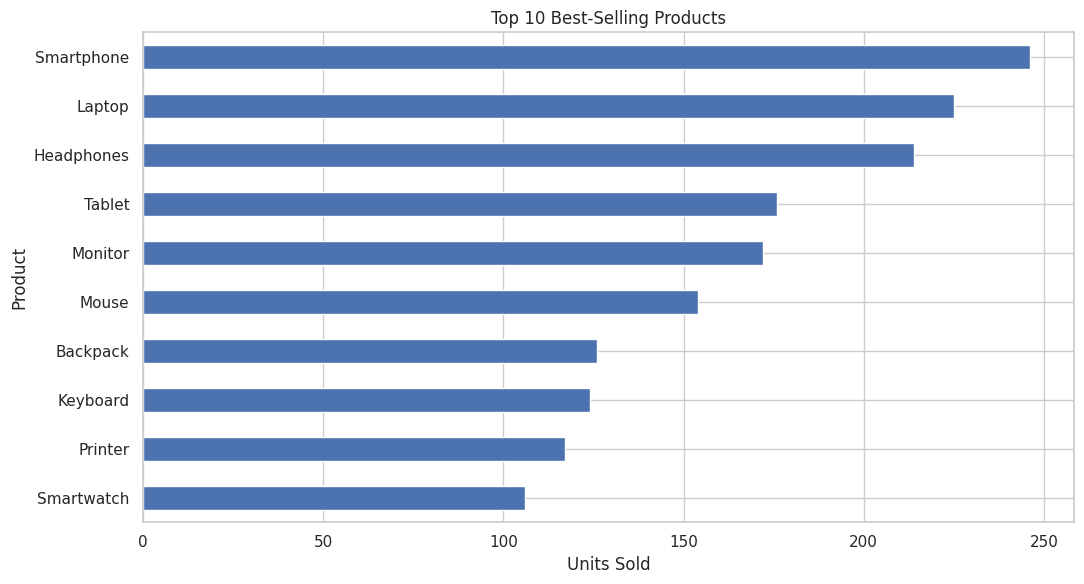

,Units Sold
Product,
Smartphone,246
Laptop,225
Headphones,214
Tablet,176
Monitor,172
Mouse,154
Backpack,126
Keyboard,124
Printer,117


In [ ]:
# 8. Top 10 best-selling products
if PRODUCT_COL:
    if QTY_COL:
        top_products = df.groupby(PRODUCT_COL)[QTY_COL].sum().sort_values(ascending=False).head(10)
        metric = "Units Sold"
    else:
        top_products = df[PRODUCT_COL].value_counts().head(10)
        metric = "Number of Transactions"

    ax = top_products.sort_values().plot(kind="barh")
    ax.set_title("Top 10 Best-Selling Products")
    ax.set_xlabel(metric)
    ax.set_ylabel("Product")
    plt.tight_layout()
    plt.show()

    display(top_products.to_frame(metric))
else:
    print("Product analysis requires a product column.")


### Observation

The leading products represent the highest-volume items under the selected metric. These products may deserve close attention to stock availability, replenishment frequency, and cross-selling opportunities.


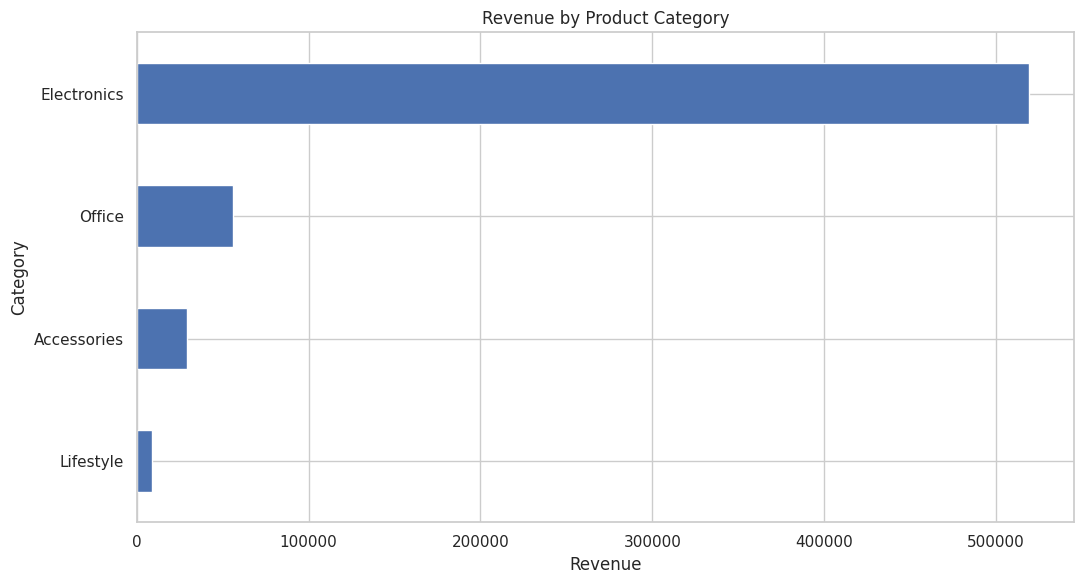

,Revenue
Category,
Electronics,519484.97
Office,56228.69
Accessories,29123.52
Lifestyle,9083.73


In [ ]:
# 9. Revenue by product category
if CATEGORY_COL and SALES_COL:
    category_revenue = df.groupby(CATEGORY_COL)[SALES_COL].sum().sort_values(ascending=True)

    ax = category_revenue.plot(kind="barh")
    ax.set_title("Revenue by Product Category")
    ax.set_xlabel("Revenue")
    ax.set_ylabel("Category")
    plt.tight_layout()
    plt.show()

    display(category_revenue.sort_values(ascending=False).to_frame("Revenue"))
else:
    print("Category revenue analysis requires category and sales/revenue columns.")


### Observation

Compare categories by total revenue rather than transaction count alone. A category with fewer transactions can still generate substantial revenue if its average transaction value is higher.


## 6. Correlation analysis

A correlation matrix helps identify numerical variables that move together. Correlation is descriptive and does not establish causation.


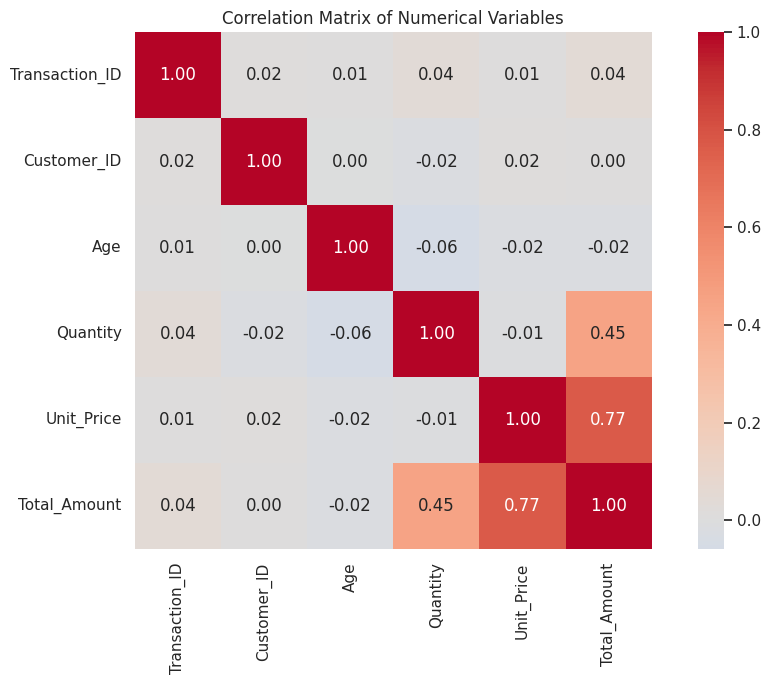

In [ ]:
# 10. Correlation heatmap
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlation Matrix of Numerical Variables")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numerical columns are needed for a correlation matrix.")


### Observation

Focus on strong positive or negative relationships and consider whether they are structurally expected. For example, quantity and sales may correlate because revenue can be constructed from quantity and price; this should not be interpreted as an independent causal relationship.


## 7. Additional visualisation — transaction value by age group

A useful non-obvious analysis is to compare **average transaction value across customer age groups**. This can reveal segments that are not necessarily the largest by customer count but contribute more value per transaction.


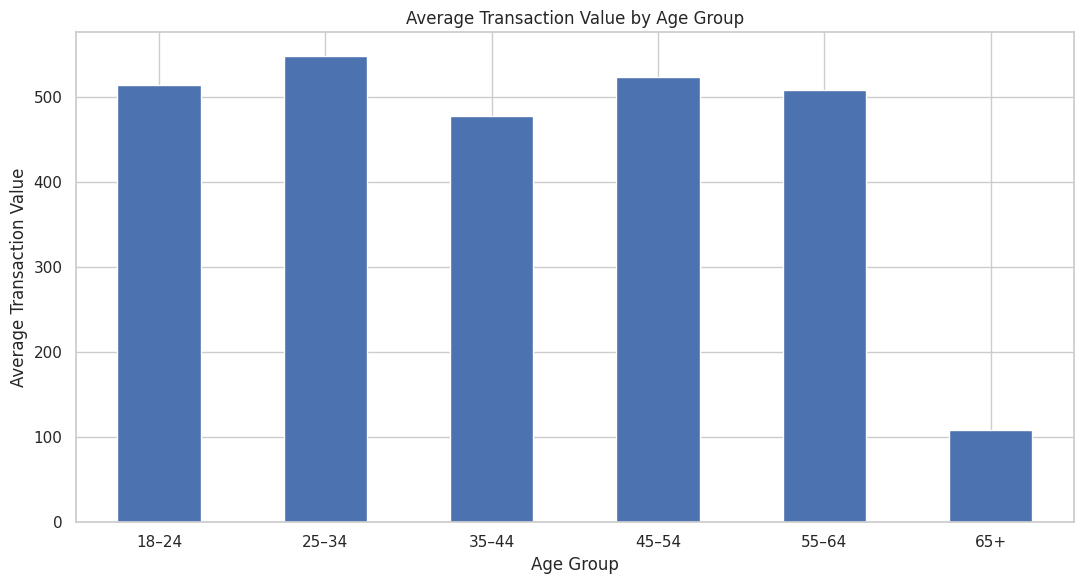

,Average Transaction Value
Age Group,
18–24,514.404396
25–34,548.891455
35–44,477.628177
45–54,523.825837
55–64,509.012982
65+,109.056667


In [ ]:
# 11. Additional insight: average transaction value by age group
if AGE_COL and SALES_COL:
    tmp = df[[AGE_COL, SALES_COL]].dropna().copy()
    tmp["Age Group"] = pd.cut(
        tmp[AGE_COL],
        bins=[0, 17, 24, 34, 44, 54, 64, np.inf],
        labels=["<18", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
    )

    avg_value = tmp.groupby("Age Group", observed=False)[SALES_COL].mean().dropna()

    ax = avg_value.plot(kind="bar")
    ax.set_title("Average Transaction Value by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Average Transaction Value")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    display(avg_value.to_frame("Average Transaction Value"))
else:
    print("Additional age-value analysis requires age and sales/revenue columns.")


### Observation

Compare the average transaction value with the earlier age-group counts. A smaller customer segment with a higher average transaction value can represent a meaningful commercial opportunity even if it is not the largest segment.


## 8. Optional deeper analysis: sales distribution

A histogram of transaction values can reveal whether revenue is concentrated around a typical purchase size or driven by a small number of unusually large transactions.


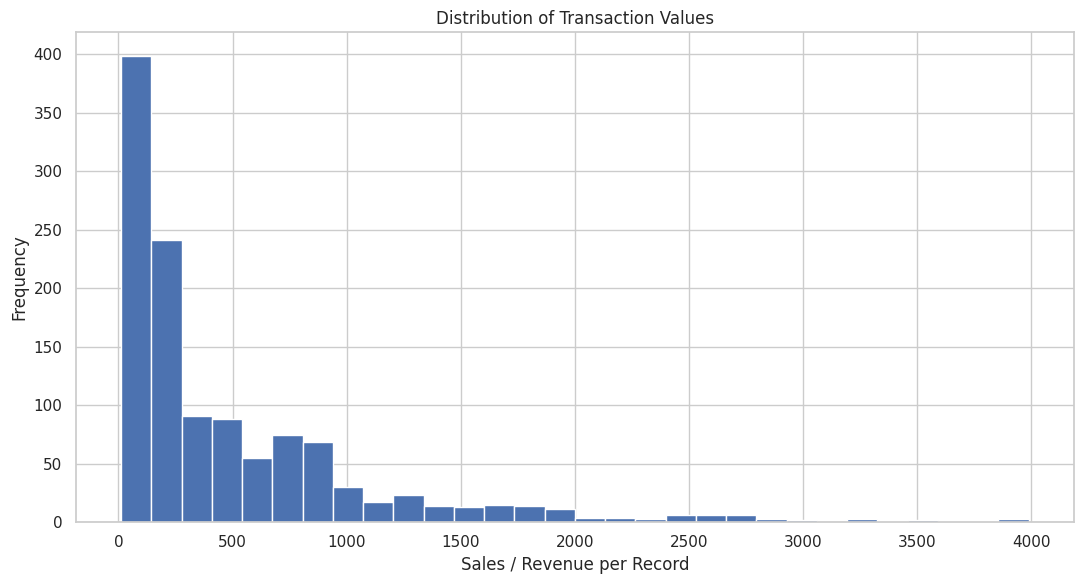

In [ ]:
# 12. Distribution of transaction values
if SALES_COL:
    ax = df[SALES_COL].dropna().plot(kind="hist", bins=30)
    ax.set_title("Distribution of Transaction Values")
    ax.set_xlabel("Sales / Revenue per Record")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Transaction distribution requires a sales/revenue column.")


### Observation

A long right tail indicates that a relatively small number of high-value transactions may contribute disproportionately to revenue. Such transactions should be investigated separately from the typical customer purchase.


# 9. Conclusion and actionable business recommendations

Based on the patterns identified in this notebook, translate the actual findings into recommendations using the structure below.

### Recommendation 1 — Inventory and replenishment
Prioritize monitoring and replenishment for the products that consistently rank among the highest sellers. If the monthly/quarterly charts show predictable peaks, increase inventory ahead of those periods to reduce stockout risk.

### Recommendation 2 — Category-level resource allocation
Use the revenue-by-category results to focus merchandising, promotional space, and assortment reviews on categories that contribute substantial revenue. Investigate whether lower-revenue categories have weak demand, low average transaction value, or limited availability.

### Recommendation 3 — Customer segmentation
Use the age-group and gender distributions together with average transaction value to distinguish **customer volume** from **customer value**. Tailor campaigns to segments supported by the observed purchasing data rather than demographic assumptions alone.

### Recommendation 4 — Seasonal planning
If the monthly and quarterly trends show recurring peaks, align promotions, staffing, procurement, and inventory levels with those periods. Monitor the same periods in future months/quarters to test whether the pattern persists.

### Recommendation 5 — High-value transaction strategy
If the transaction-value distribution shows a strong upper tail or certain age groups/categories have materially higher average transaction values, investigate the characteristics of those purchases and consider bundles, premium products, or cross-selling strategies.

> **Final step:** Replace the generic recommendation wording above with specific figures from your dataset (for example, the highest-revenue category, strongest month/quarter, and highest-value customer segment) before submitting the notebook.


## 10. Reproducibility notes

- The notebook uses pandas for data manipulation and matplotlib/seaborn for visualization.
- Column detection supports common retail dataset naming conventions, but the detected columns should always be reviewed.
- Missing or incorrectly typed fields can affect downstream results.
- Correlation and demographic comparisons are descriptive; they should not be interpreted as causal evidence without further analysis.
